<a href="https://colab.research.google.com/github/aparna-2001/system-biology/blob/main/systems_biologyipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y numpy scipy
!pip install tellurium


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 65.5 MB/s eta 0:00:00
   ━━

In [ ]:
import tellurium as te
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import networkx as nx

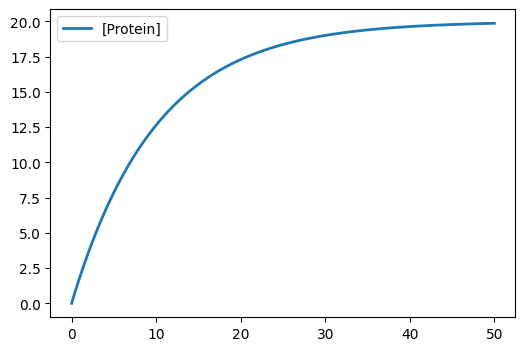

In [ ]:


# A simple gene that produces protein and degrades it
model = te.loada('''
  production: -> Protein; k1
  degradation: Protein -> ; k2 * Protein

  k1 = 2.0    # production rate
  k2 = 0.1   # degradation rate
  Protein = 0 # starting amount
''')

result = model.simulate(0, 50, 500)
model.plot()

/tmp/ipykernel_3306/1679834414.py:30: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



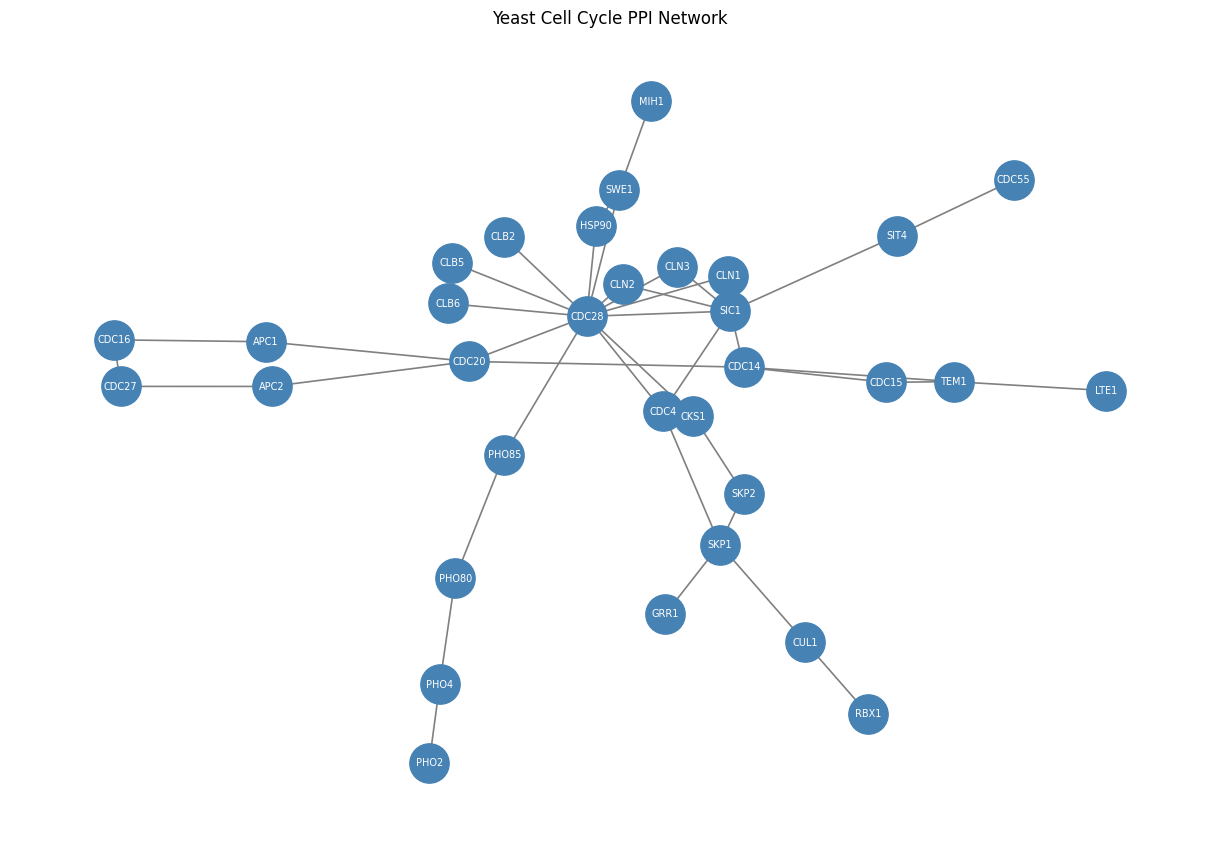

Nodes (proteins): 33
Edges (interactions): 41


In [ ]:


# Real yeast PPI data — curated high-confidence interactions
# Source: BioGRID / Jeong et al. 2001 (Nature) core dataset
edges = [
    ("CDC28","CLN1"),("CDC28","CLN2"),("CDC28","CLN3"),
    ("CDC28","SIC1"),("CDC28","CDC20"),("CDC28","CKS1"),
    ("CLN1","SIC1"),("CLN2","SIC1"),("CLN3","SIC1"),
    ("SIC1","CDC4"),("CDC4","SKP1"),("SKP1","CUL1"),
    ("CUL1","RBX1"),("CDC20","APC1"),("APC1","CDC16"),
    ("CDC16","CDC27"),("CDC27","APC2"),("APC2","CDC20"),
    ("CKS1","SKP2"),("SKP2","SKP1"),("CLN1","CDC28"),
    ("SWE1","CDC28"),("MIH1","SWE1"),("HSP90","CDC28"),
    ("HSP90","SWE1"),("CDC55","SIT4"),("SIT4","SIC1"),
    ("CDC14","SIC1"),("CDC14","CDC20"),("TEM1","CDC14"),
    ("LTE1","TEM1"),("CDC15","TEM1"),("CDC15","CDC14"),
    ("CLB2","CDC28"),("CLB5","CDC28"),("CLB6","CDC28"),
    ("CDC28","PHO85"),("PHO85","PHO80"),("PHO80","PHO4"),
    ("PHO4","PHO2"),("GRR1","SKP1"),("CDC4","CDC28")
]

G = nx.Graph()
G.add_edges_from(edges)

# Visualize it
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
plt.title("Yeast Cell Cycle PPI Network")
plt.tight_layout()
plt.show()

print(f"Nodes (proteins): {G.number_of_nodes()}")
print(f"Edges (interactions): {G.number_of_edges()}")

In [ ]:
# Degree of every protein
degree_dict = dict(G.degree())

for protein, deg in sorted(degree_dict.items(), key=lambda x: -x[1]):
    print(f"{protein}: {deg}")

CDC28: 13
SIC1: 7
CDC20: 4
SKP1: 4
CDC14: 4
CDC4: 3
SWE1: 3
TEM1: 3
CLN1: 2
CLN2: 2
CLN3: 2
CKS1: 2
CUL1: 2
APC1: 2
CDC16: 2
CDC27: 2
APC2: 2
SKP2: 2
HSP90: 2
SIT4: 2
CDC15: 2
PHO85: 2
PHO80: 2
PHO4: 2
RBX1: 1
MIH1: 1
CDC55: 1
LTE1: 1
CLB2: 1
CLB5: 1
CLB6: 1
PHO2: 1
GRR1: 1


/tmp/ipykernel_3306/1606370019.py:9: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



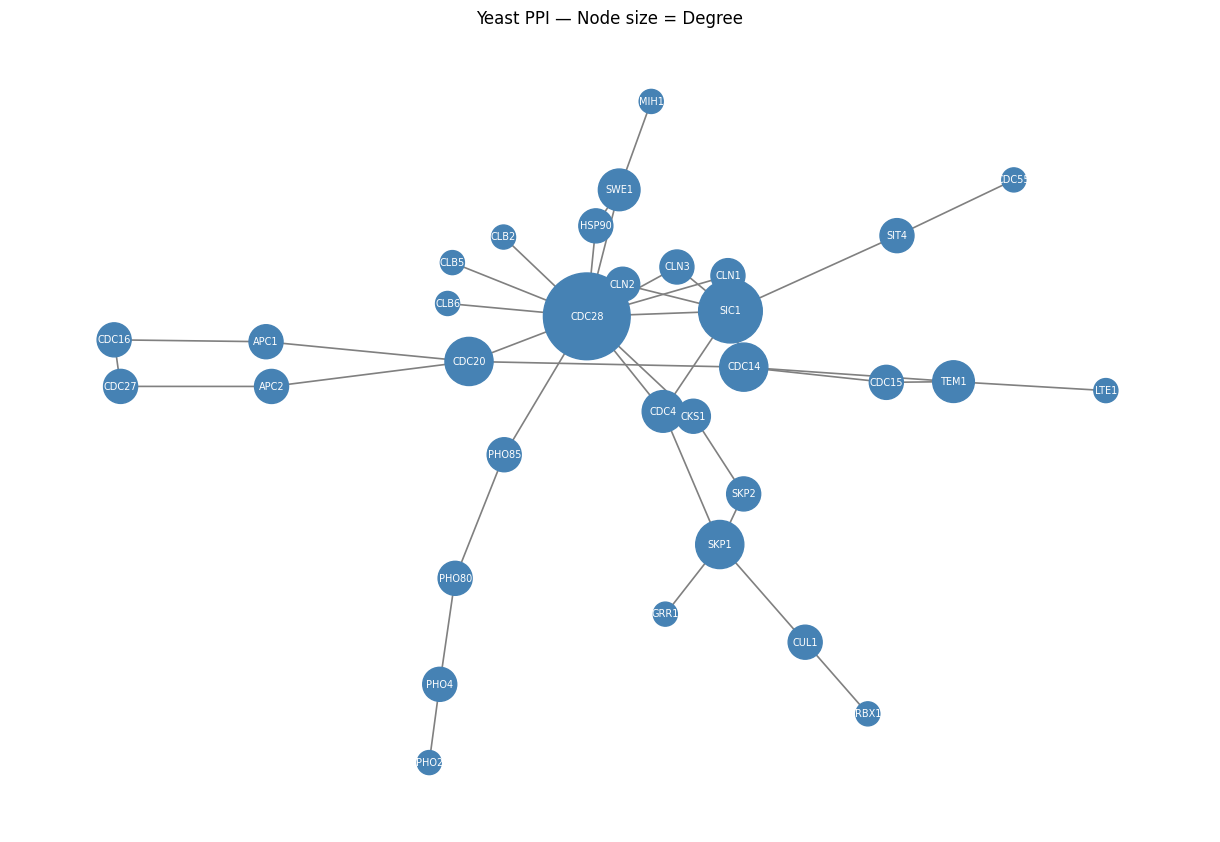

In [ ]:
# Visualize with node size proportional to degree
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
node_sizes = [degree_dict[n] * 300 for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=node_sizes, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
plt.title("Yeast PPI — Node size = Degree")
plt.tight_layout()
plt.show()

In [ ]:
# What happens to the network if we remove CDC28?
G_removed = G.copy()
G_removed.remove_node("CDC28")

# Count connected components
components = list(nx.connected_components(G_removed))
print(f"Components after removing CDC28: {len(components)}")
print()
for i, comp in enumerate(components):
    print(f"Component {i+1}: {comp}")

Components after removing CDC28: 6

Component 1: {'SIT4', 'CDC15', 'CDC20', 'CLN1', 'CDC55', 'LTE1', 'CDC16', 'CDC4', 'SIC1', 'SKP2', 'CKS1', 'RBX1', 'TEM1', 'SKP1', 'CUL1', 'GRR1', 'CDC27', 'APC2', 'APC1', 'CDC14', 'CLN3', 'CLN2'}
Component 2: {'MIH1', 'HSP90', 'SWE1'}
Component 3: {'CLB2'}
Component 4: {'CLB5'}
Component 5: {'CLB6'}
Component 6: {'PHO85', 'PHO4', 'PHO2', 'PHO80'}


In [ ]:
#density

density = nx.density(G)
print(f"Network density: {density:.4f}")

# For context, let's see what density 1.0 would look like
n = G.number_of_nodes()
max_possible_edges = n * (n-1) / 2
actual_edges = G.number_of_edges()

print(f"Proteins in network: {n}")
print(f"Actual interactions: {actual_edges}")
print(f"Maximum possible interactions: {int(max_possible_edges)}")
print(f"Percentage of possible interactions that exist: {density*100:.2f}%")

Network density: 0.0777
Proteins in network: 33
Actual interactions: 41
Maximum possible interactions: 528
Percentage of possible interactions that exist: 7.77%


Shortest path from SIC1 to PHO4: ['SIC1', 'CDC28', 'PHO85', 'PHO80', 'PHO4']
Path length: 4 steps

Characteristic path length: 3.4432


/tmp/ipykernel_3306/3334594351.py:22: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



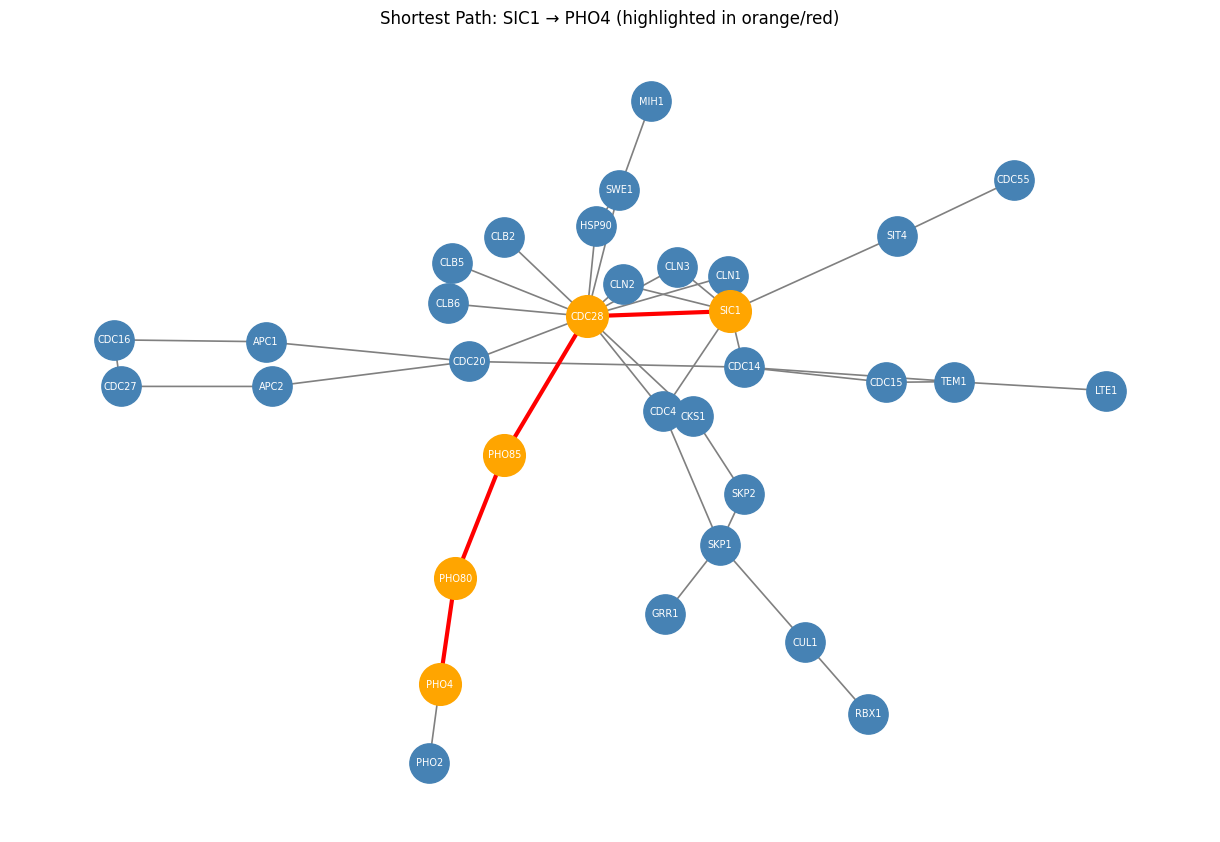

In [ ]:
# Shortest path between two specific proteins
path = nx.shortest_path(G, "SIC1", "PHO4")
print(f"Shortest path from SIC1 to PHO4: {path}")
print(f"Path length: {len(path)-1} steps")

# Characteristic path length (average shortest path)
avg_path = nx.average_shortest_path_length(G)
print(f"\nCharacteristic path length: {avg_path:.4f}")

# Visualize the path
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path, path[1:]))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='red', width=3)
nx.draw_networkx_nodes(G, pos, nodelist=path,
                       node_color='orange', node_size=900)
plt.title("Shortest Path: SIC1 → PHO4 (highlighted in orange/red)")
plt.tight_layout()
plt.show()

Shortest path from SIC1 to SKP1: ['SIC1', 'CDC4', 'SKP1']
Path length: 4 steps


/tmp/ipykernel_3306/4130741712.py:19: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



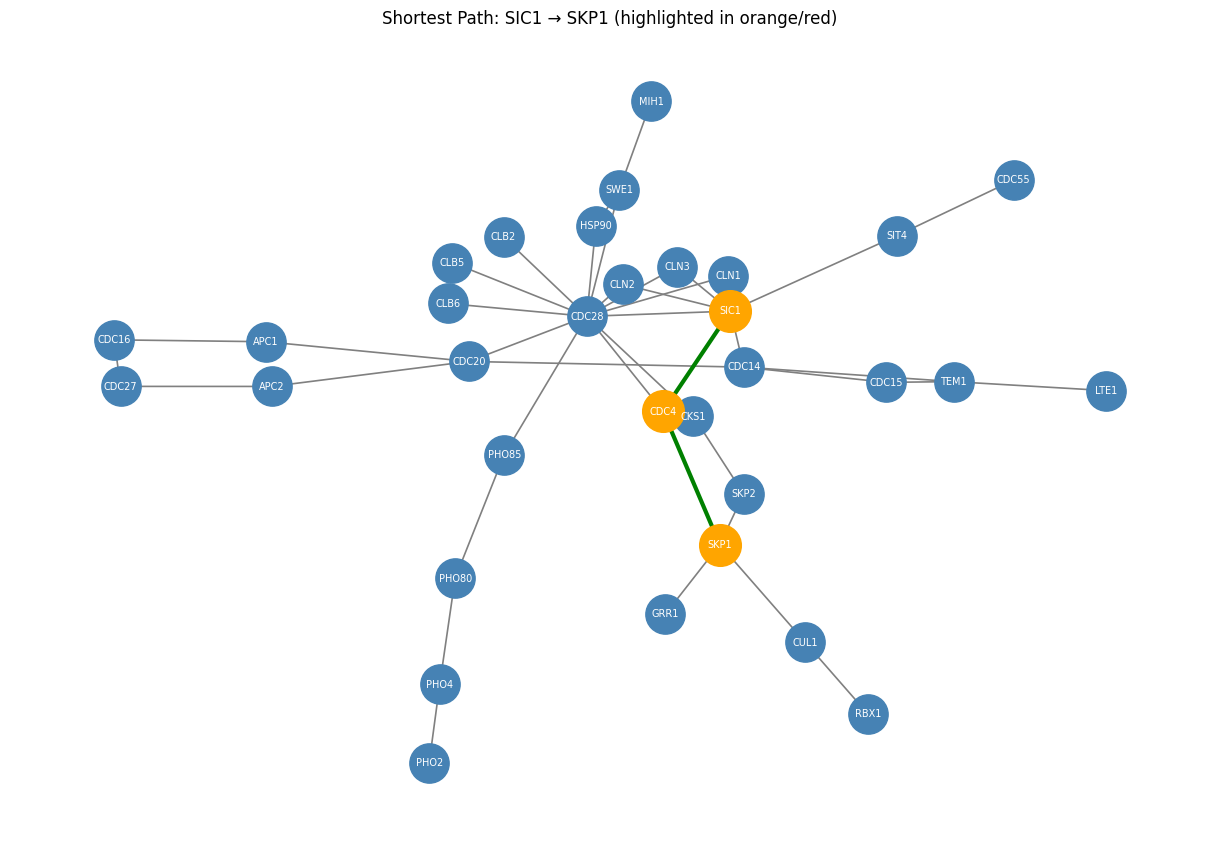

In [ ]:
# Shortest path between two specific proteins
path_2 = nx.shortest_path(G, "SIC1", "SKP1")
print(f"Shortest path from SIC1 to SKP1: {path_2}")
print(f"Path length: {len(path)-1} steps")


# Visualize the path
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
path_edges = list(zip(path_2, path_2[1:]))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_size=7, font_color='white',
        edge_color='gray', width=1.2)
nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                       edge_color='green', width=3)
nx.draw_networkx_nodes(G, pos, nodelist=path_2,
                       node_color='orange', node_size=900)
plt.title("Shortest Path: SIC1 → SKP1 (highlighted in orange/red)")
plt.tight_layout()
plt.show()


In [ ]:
# Diameter of the network
diameter = nx.diameter(G)
print(f"Network diameter: {diameter}")

# Find which two proteins are furthest apart
periphery = nx.periphery(G)
center = nx.center(G)

print(f"\nPeriphery proteins (furthest from everything): {periphery}")
print(f"Center proteins (closest to everything): {center}")

# Find the actual longest shortest path
eccentricities = nx.eccentricity(G)
for protein, ecc in sorted(eccentricities.items(), key=lambda x: -x[1]):
    print(f"{protein}: eccentricity {ecc}")





Network diameter: 8

Periphery proteins (furthest from everything): ['RBX1', 'LTE1', 'PHO2']
Center proteins (closest to everything): ['CDC28']
RBX1: eccentricity 8
LTE1: eccentricity 8
PHO2: eccentricity 8
CUL1: eccentricity 7
CDC16: eccentricity 7
CDC27: eccentricity 7
CDC55: eccentricity 7
TEM1: eccentricity 7
CDC15: eccentricity 7
PHO4: eccentricity 7
GRR1: eccentricity 7
SKP1: eccentricity 6
APC1: eccentricity 6
APC2: eccentricity 6
SKP2: eccentricity 6
MIH1: eccentricity 6
SIT4: eccentricity 6
CDC14: eccentricity 6
PHO80: eccentricity 6
CLN1: eccentricity 5
CLN2: eccentricity 5
CLN3: eccentricity 5
SIC1: eccentricity 5
CDC20: eccentricity 5
CKS1: eccentricity 5
CDC4: eccentricity 5
SWE1: eccentricity 5
HSP90: eccentricity 5
CLB2: eccentricity 5
CLB5: eccentricity 5
CLB6: eccentricity 5
PHO85: eccentricity 5
CDC28: eccentricity 4


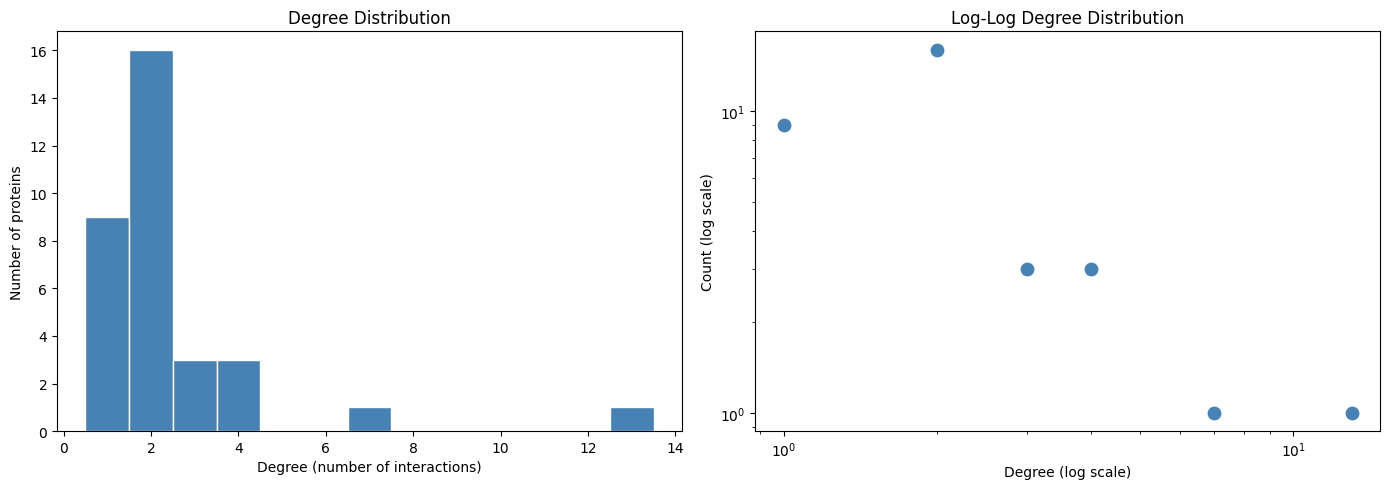

Degree : Number of proteins
  Degree  1 : 9 proteins  █████████
  Degree  2 : 16 proteins  ████████████████
  Degree  3 : 3 proteins  ███
  Degree  4 : 3 proteins  ███
  Degree  7 : 1 proteins  █
  Degree 13 : 1 proteins  █


In [ ]:


# Get degree of all proteins
degrees = [d for n, d in G.degree()]

# Plot degree distribution
plt.figure(figsize=(14,5))

# Plot 1 — Raw distribution
plt.subplot(1,2,1)
plt.hist(degrees, bins=range(1, max(degrees)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel("Degree (number of interactions)")
plt.ylabel("Number of proteins")
plt.title("Degree Distribution")

# Plot 2 — Log-log plot
plt.subplot(1,2,2)
degree_counts = {}
for d in degrees:
    degree_counts[d] = degree_counts.get(d, 0) + 1

x = list(degree_counts.keys())
y = list(degree_counts.values())

plt.scatter(x, y, color='steelblue', s=80)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree (log scale)")
plt.ylabel("Count (log scale)")
plt.title("Log-Log Degree Distribution")

plt.tight_layout()
plt.show()

# Print the distribution
print("Degree : Number of proteins")
for deg, count in sorted(degree_counts.items()):
    print(f"  Degree {deg:2d} : {count} proteins  {'█' * count}")


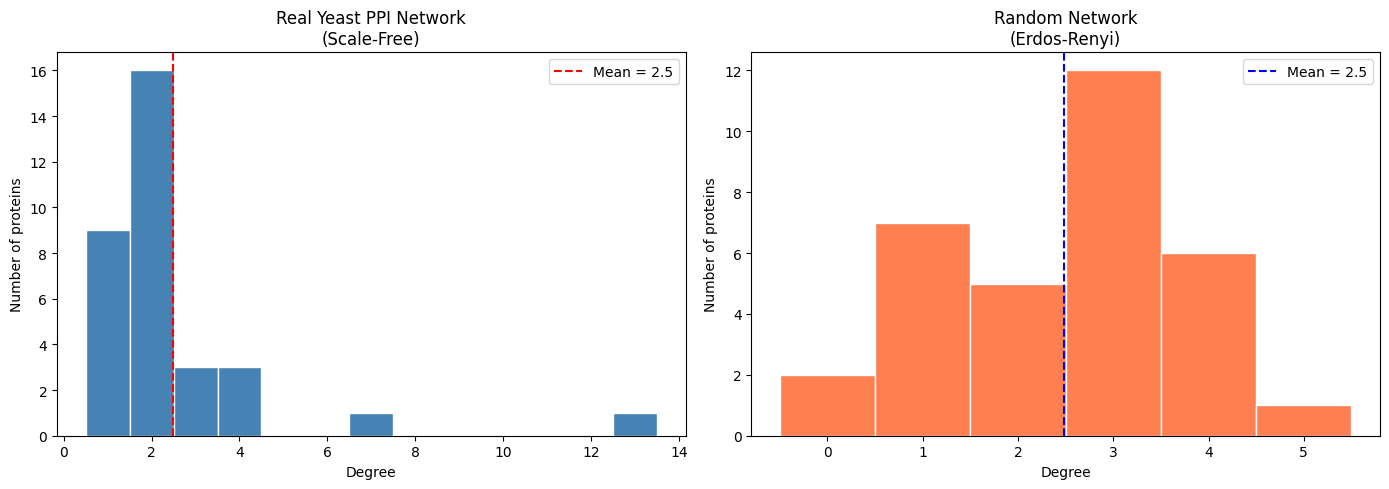

In [ ]:
# Compare real network vs random network degree distribution
plt.figure(figsize=(14,5))

# Real network
plt.subplot(1,2,1)
real_degrees = [d for n, d in G.degree()]
plt.hist(real_degrees, bins=range(1, max(real_degrees)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel("Degree")
plt.ylabel("Number of proteins")
plt.title("Real Yeast PPI Network\n(Scale-Free)")
plt.axvline(np.mean(real_degrees), color='red',
            linestyle='--', label=f'Mean = {np.mean(real_degrees):.1f}')
plt.legend()

# Random network with same number of nodes and edges
random_G = nx.erdos_renyi_graph(G.number_of_nodes(),
                                 nx.density(G), seed=42)
random_degrees = [d for n, d in random_G.degree()]

plt.subplot(1,2,2)
plt.hist(random_degrees, bins=range(0, max(random_degrees)+2),
         color='coral', edgecolor='white', align='left')
plt.xlabel("Degree")
plt.ylabel("Number of proteins")
plt.title("Random Network\n(Erdos-Renyi)")
plt.axvline(np.mean(random_degrees), color='blue',
            linestyle='--', label=f'Mean = {np.mean(random_degrees):.1f}')
plt.legend()

plt.tight_layout()
plt.show()

Protein : Clustering Coefficient
----------------------------------------
CLN1       : 1.000  ████████████████████
CLN2       : 1.000  ████████████████████
CLN3       : 1.000  ████████████████████
HSP90      : 1.000  ████████████████████
CDC15      : 1.000  ████████████████████
CDC4       : 0.333  ██████
SWE1       : 0.333  ██████
TEM1       : 0.333  ██████
SIC1       : 0.190  ███
CDC14      : 0.167  ███
CDC28      : 0.064  █
CDC20      : 0.000  
CKS1       : 0.000  
SKP1       : 0.000  
CUL1       : 0.000  
RBX1       : 0.000  
APC1       : 0.000  
CDC16      : 0.000  
CDC27      : 0.000  
APC2       : 0.000  
SKP2       : 0.000  
MIH1       : 0.000  
CDC55      : 0.000  
SIT4       : 0.000  
LTE1       : 0.000  
CLB2       : 0.000  
CLB5       : 0.000  
CLB6       : 0.000  
PHO85      : 0.000  
PHO80      : 0.000  
PHO4       : 0.000  
PHO2       : 0.000  
GRR1       : 0.000  

Average clustering coefficient: 0.1946


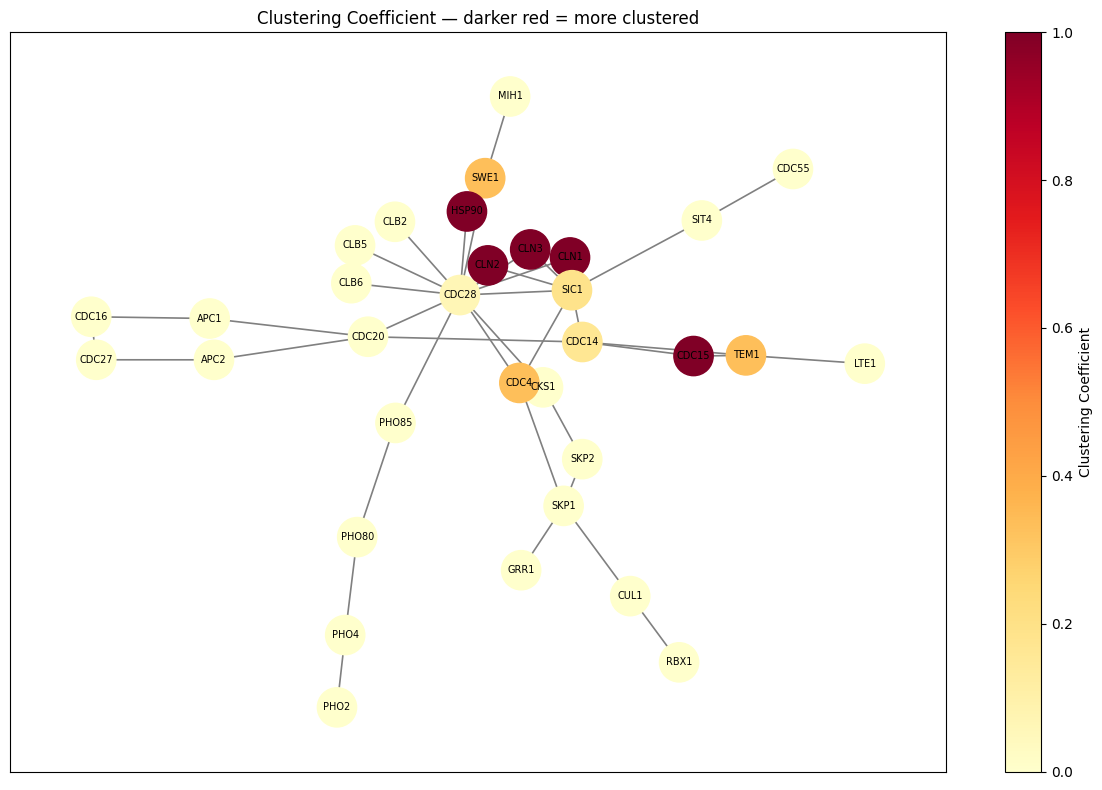

In [ ]:
# Local clustering coefficient for each protein
clustering = nx.clustering(G)

print("Protein : Clustering Coefficient")
print("-" * 40)
for protein, cc in sorted(clustering.items(), key=lambda x: -x[1]):
    bar = '█' * int(cc * 20)
    print(f"{protein:10s} : {cc:.3f}  {bar}")

# Global clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f"\nAverage clustering coefficient: {avg_clustering:.4f}")

# Visualize — node color = clustering coefficient
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
cc_values = [clustering[n] for n in G.nodes()]
nodes = nx.draw_networkx_nodes(G, pos, node_color=cc_values,
                                cmap=plt.cm.YlOrRd,
                                node_size=800)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='black')
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.2)
plt.colorbar(nodes, label='Clustering Coefficient')
plt.title("Clustering Coefficient — darker red = more clustered")
plt.tight_layout()
plt.show()

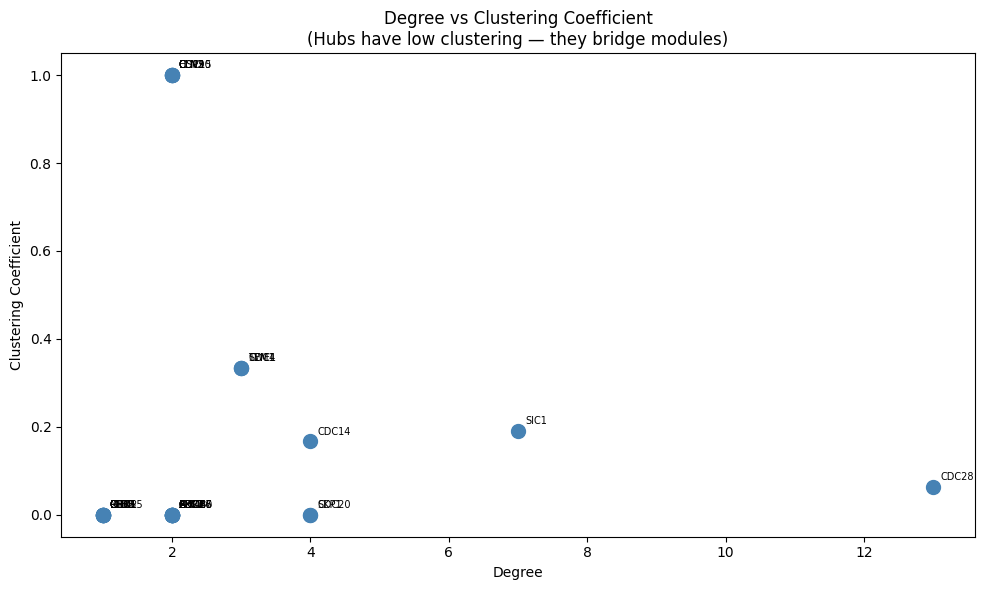

In [ ]:
# Plot degree vs clustering coefficient
plt.figure(figsize=(10,6))
degrees_list = [G.degree(n) for n in G.nodes()]
clustering_list = [clustering[n] for n in G.nodes()]
labels = list(G.nodes())

plt.scatter(degrees_list, clustering_list,
            color='steelblue', s=100, zorder=5)

# Label each point
for i, label in enumerate(labels):
    plt.annotate(label,
                (degrees_list[i], clustering_list[i]),
                textcoords="offset points",
                xytext=(5,5), fontsize=7)

plt.xlabel("Degree")
plt.ylabel("Clustering Coefficient")
plt.title("Degree vs Clustering Coefficient\n(Hubs have low clustering — they bridge modules)")
plt.tight_layout()
plt.show()

Protein : Closeness Centrality
---------------------------------------------
CDC28      : 0.4923  ██████████████
SIC1       : 0.4211  ████████████
CDC20      : 0.4000  ████████████
CDC4       : 0.4000  ████████████
CLN1       : 0.3596  ██████████
CLN2       : 0.3596  ██████████
CLN3       : 0.3596  ██████████
CKS1       : 0.3556  ██████████
PHO85      : 0.3556  ██████████
CDC14      : 0.3516  ██████████
SWE1       : 0.3441  ██████████
HSP90      : 0.3404  ██████████
CLB2       : 0.3333  ██████████
CLB5       : 0.3333  ██████████
CLB6       : 0.3333  ██████████
SKP1       : 0.3137  █████████
SIT4       : 0.3048  █████████
APC1       : 0.2963  ████████
APC2       : 0.2963  ████████
SKP2       : 0.2857  ████████
PHO80      : 0.2735  ████████
TEM1       : 0.2689  ████████
CDC15      : 0.2667  ████████
MIH1       : 0.2581  ███████
CUL1       : 0.2443  ███████
GRR1       : 0.2406  ███████
CDC16      : 0.2353  ███████
CDC27      : 0.2353  ███████
CDC55      : 0.2353  ███████
PHO4       : 0.21

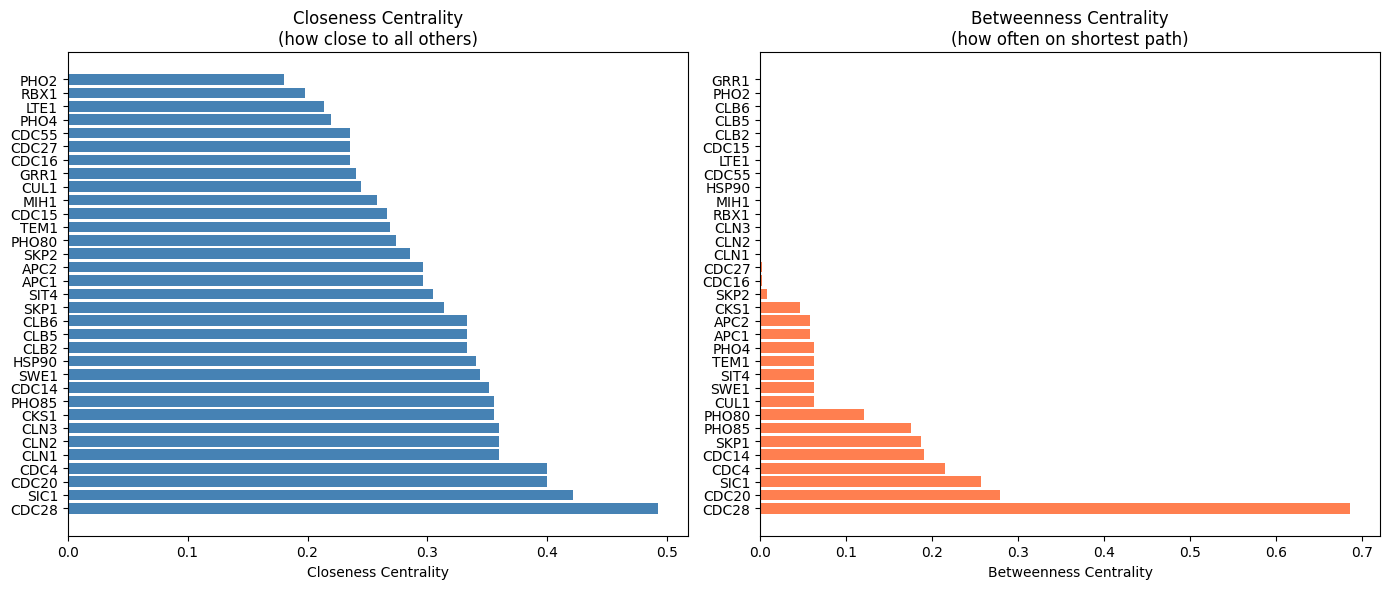

In [ ]:
# Closeness centrality
closeness = nx.closeness_centrality(G)

print("Protein : Closeness Centrality")
print("-" * 45)
for protein, cc in sorted(closeness.items(), key=lambda x: -x[1]):
    bar = '█' * int(cc * 30)
    print(f"{protein:10s} : {cc:.4f}  {bar}")

# Betweenness centrality — how often does a protein
# sit on the shortest path between two other proteins
betweenness = nx.betweenness_centrality(G)

print("\nProtein : Betweenness Centrality")
print("-" * 45)
for protein, bc in sorted(betweenness.items(), key=lambda x: -x[1]):
    bar = '█' * int(bc * 40)
    print(f"{protein:10s} : {bc:.4f}  {bar}")

# Plot both together
plt.figure(figsize=(14,6))

proteins = list(G.nodes())
close_vals = [closeness[p] for p in proteins]
between_vals = [betweenness[p] for p in proteins]

plt.subplot(1,2,1)
sorted_close = sorted(closeness.items(), key=lambda x: -x[1])
plt.barh([x[0] for x in sorted_close],
         [x[1] for x in sorted_close],
         color='steelblue')
plt.xlabel("Closeness Centrality")
plt.title("Closeness Centrality\n(how close to all others)")
plt.tight_layout()

plt.subplot(1,2,2)
sorted_between = sorted(betweenness.items(), key=lambda x: -x[1])
plt.barh([x[0] for x in sorted_between],
         [x[1] for x in sorted_between],
         color='coral')
plt.xlabel("Betweenness Centrality")
plt.title("Betweenness Centrality\n(how often on shortest path)")
plt.tight_layout()

plt.tight_layout()
plt.show()